## **LEVEL 1**

**TASK 1 - Data Exploration and Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Dataset .csv")
df.head()

Saving Dataset .csv to Dataset  (1).csv


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.shape

(9551, 21)

The dataset contains 9,551 rows and 21 columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

The dataset contains both numerical and categorical features.

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


A few missing values were found in the dataset.


In [ ]:
df.ffill(inplace=True)

Missing values were handled using forward fill to maintain data consistency and avoid information loss.

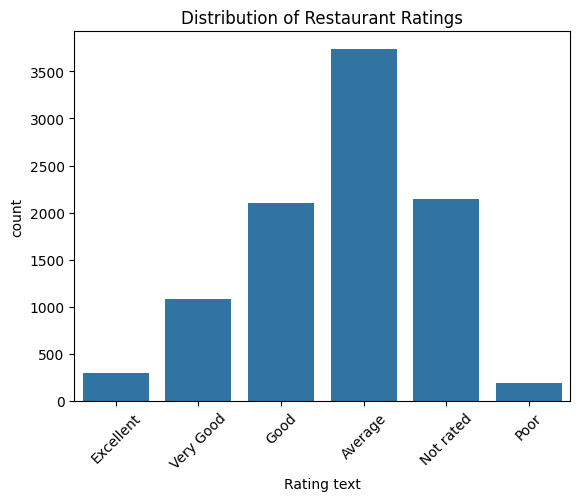

In [ ]:
sns.countplot(x='Rating text', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Restaurant Ratings")
plt.show()


The rating distribution shows class imbalance, where most restaurants fall under average or unrated categories.

**TASK 2 - Descriptive Analysis**

In [ ]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


The numerical analysis shows that most restaurants have moderate aggregate ratings, indicating an overall average customer experience across the dataset.

In [ ]:
df['City'].value_counts().head(10)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Lucknow,21
Ahmedabad,21
Amritsar,21


A small number of cities contribute a large proportion of restaurants, showing that restaurant listings are concentrated in major urban areas.

In [ ]:
df['Cuisines'].value_counts().head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,355
Fast Food,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


Certain cuisines appear more frequently than others, indicating common food preferences among customers across different locations.

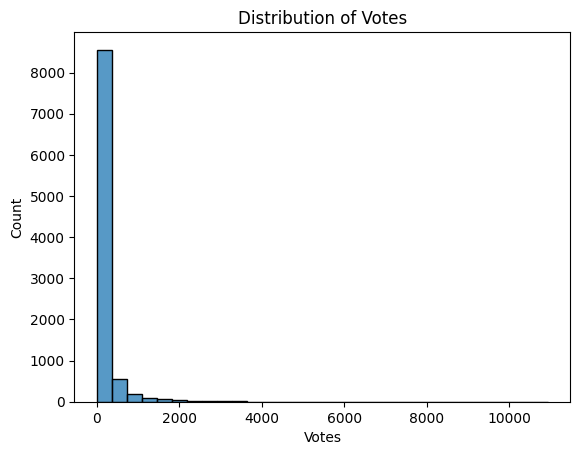

In [ ]:
sns.histplot(df['Votes'], bins=30)
plt.title("Distribution of Votes")
plt.show()

Most restaurants have received a limited number of votes, while only a few restaurants have high customer engagement.

**TASK 3 - Geospatial Analysis**

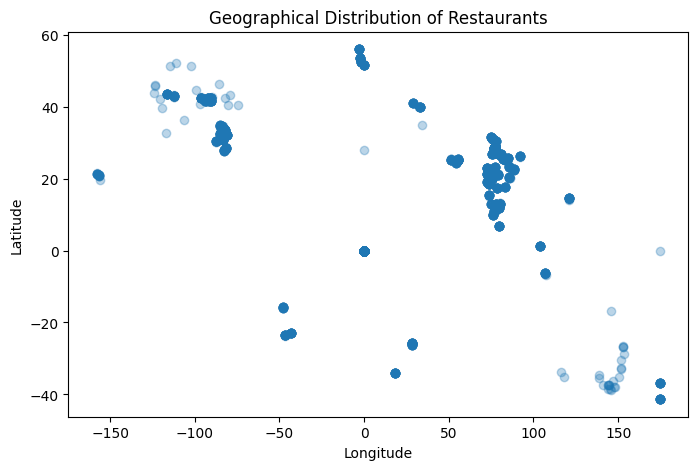

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Restaurants")
plt.show()

The scatter plot shows that restaurants are concentrated in specific geographic regions, indicating higher restaurant density in urban areas.

In [ ]:
df['Country Code'].value_counts()


,count
Country Code,
1,8652
216,434
215,80
30,60
189,60
214,60
148,40
208,34
14,24


The dataset contains restaurants from multiple countries, with a higher concentration of restaurants in a few countries.

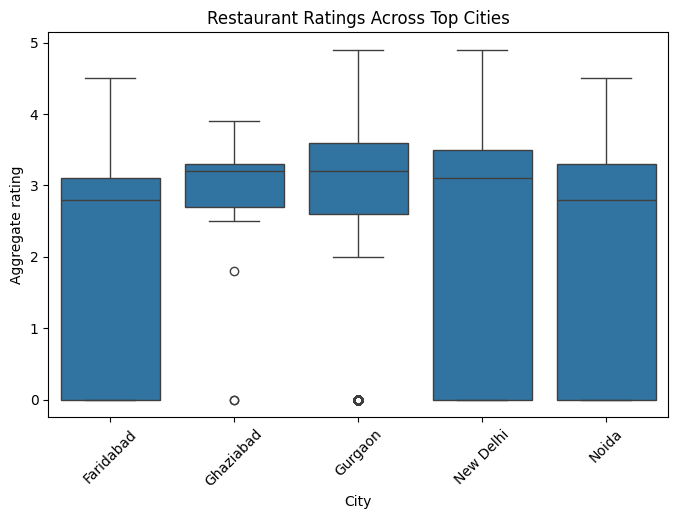

In [ ]:
top_cities = df['City'].value_counts().head(5).index

plt.figure(figsize=(8,5))
sns.boxplot(x='City', y='Aggregate rating', data=df[df['City'].isin(top_cities)])
plt.xticks(rotation=45)
plt.title("Restaurant Ratings Across Top Cities")
plt.show()

The rating distribution varies across cities, indicating that geographical location has an influence on restaurant ratings.

# **LEVEL 2**

**TASK 1 - Table Booking and Online Delivery Analysis**

In [ ]:
df['Has Table booking'].value_counts(normalize=True) * 100

,proportion
Has Table booking,
No,87.875615
Yes,12.124385


The majority of restaurants do not offer table booking facilities, while only a smaller percentage provide this service.

In [ ]:
df['Has Online delivery'].value_counts(normalize=True) * 100

,proportion
Has Online delivery,
No,74.337766
Yes,25.662234


Online delivery is available for a limited number of restaurants, indicating that dine-in services are more common in the dataset.

In [ ]:
df.groupby('Has Table booking')['Aggregate rating'].mean()

,Aggregate rating
Has Table booking,
No,2.559359
Yes,3.441969


Restaurants that offer table booking have a higher average rating compared to those without table booking, suggesting better perceived service quality.

In [ ]:
df.groupby('Price range')['Has Online delivery'].value_counts()

Price range  Has Online delivery
1            No                     3743
             Yes                     701
2            No                     1827
             Yes                    1286
3            No                      997
             Yes                     411
4            No                      533
             Yes                      53
Name: count, dtype: int64

Online delivery availability differs across price ranges, with mid-range priced restaurants offering delivery services more frequently than low- and high-priced restaurants.

**TASK 2 - Price Range Analysis**

In [ ]:
df['Price range'].value_counts()

,count
Price range,
1,4444
2,3113
3,1408
4,586


The price range variable is an ordinal feature where values from 1 to 4 represent increasing levels of restaurant pricing, with 1 indicating low-cost restaurants and 4 indicating premium restaurants.

Most restaurants belong to the lower and mid price range categories, indicating that budget and moderately priced restaurants are more common.

In [ ]:
df.groupby('Price range')['Aggregate rating'].mean()

,Aggregate rating
Price range,
1,1.999887
2,2.941054
3,3.683381
4,3.817918


Restaurants in higher price ranges tend to have higher average ratings, suggesting a positive relationship between price level and perceived service or food quality.

In [ ]:
df.groupby('Rating color')['Aggregate rating'].mean()

,Aggregate rating
Rating color,
Dark Green,4.659801
Green,4.168119
Orange,3.051619
Red,2.297849
White,0.000000
Yellow,3.683429


The aggregate ratings increase consistently with darker rating colors, confirming that the rating color accurately reflects the numerical rating scale.


**TASK 3 - Feature Engineering**

In [ ]:
df['Restaurant Name Length'] = df['Restaurant Name'].apply(len)

In [ ]:
df['Table Booking Binary'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Online Delivery Binary'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Restaurant Name Length', 'Table Booking Binary',
       'Online Delivery Binary'],
      dtype='object')

New features were created by extracting the length of restaurant names and converting service availability features into numerical format to support further analysis.

# **LEVEL 3**

**TASK 1 - Predictive Modeling**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [ ]:
model_df = df[['Aggregate rating',
               'Price range',
               'Votes',
               'Has Table booking',
               'Has Online delivery']]

In [ ]:
le = LabelEncoder()
model_df['Has Table booking'] = le.fit_transform(model_df['Has Table booking'])
model_df['Has Online delivery'] = le.fit_transform(model_df['Has Online delivery'])

/tmp/ipython-input-2001182794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['Has Table booking'] = le.fit_transform(model_df['Has Table booking'])
/tmp/ipython-input-2001182794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['Has Online delivery'] = le.fit_transform(model_df['Has Online delivery'])


Categorical variables were encoded into numerical form to make them suitable for regression modeling.

In [ ]:
X = model_df.drop('Aggregate rating', axis=1)
y = model_df['Aggregate rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training and testing sets using an 80–20 split to evaluate model performance.

🔹 Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

🔹 Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

🔹 Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Training regression models.

In [ ]:
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    print(name)
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2 Score:", r2_score(y_test, pred))
    print()

Linear Regression
RMSE: 1.2949157210316278
R2 Score: 0.2633012163679982

Decision Tree
RMSE: 0.4393330268508811
R2 Score: 0.9152002345653435

Random Forest
RMSE: 0.39526763870662046
R2 Score: 0.9313580734165705



Evaluating model performance.

The Random Forest model achieved better performance compared to Linear Regression and Decision Tree models, as indicated by lower RMSE and higher R² values. This suggests that ensemble-based models are more effective in capturing non-linear relationships between restaurant features and ratings.

🟢 Predictive modeling demonstrated that restaurant ratings can be reasonably estimated using features such as price range, votes, and service availability. Among the tested models, Random Forest showed the best predictive performance.


**TASK 2 - Customer Preference Analysis**

In [ ]:
df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

,Aggregate rating
Cuisines,
"Burger, Bar Food, Steak",4.9
"American, Burger, Grill",4.9
"American, Caribbean, Seafood",4.9
"American, Coffee and Tea",4.9
"Mexican, American, Healthy Food",4.9
"Italian, Bakery, Continental",4.9
"European, Contemporary",4.9
"European, German",4.9
"Continental, Indian",4.9


Some cuisines receive higher average ratings, indicating a stronger customer preference for certain types of food. However, these results may be influenced by cuisines with a limited number of restaurants.

In [ ]:
df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).head(10)

,Votes
Cuisines,
"North Indian, Mughlai",53747
North Indian,46241
"North Indian, Chinese",42012
Cafe,30657
Chinese,22085
"North Indian, Mughlai, Chinese",20115
Fast Food,17852
South Indian,16433
"Mughlai, North Indian",15275


Certain cuisines receive a significantly higher number of customer votes, suggesting greater popularity and customer engagement.

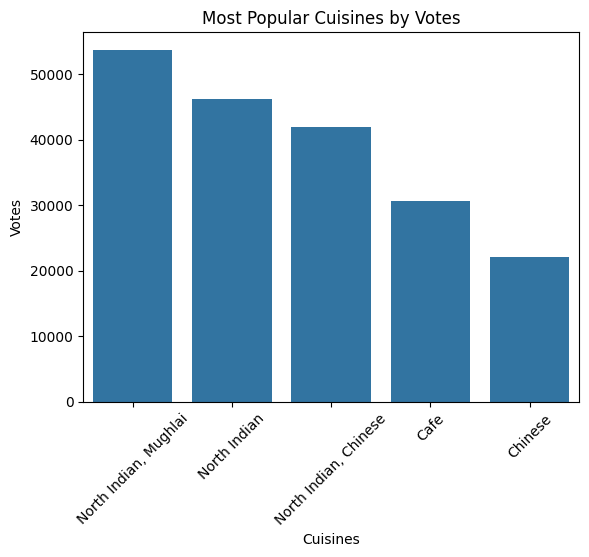

In [ ]:
top_cuisines = df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).head(5).index

sns.barplot(x=top_cuisines,
            y=df.groupby('Cuisines')['Votes'].sum().loc[top_cuisines])
plt.xticks(rotation=45)
plt.title("Most Popular Cuisines by Votes")
plt.show()

The visualization shows that a small number of cuisines dominate customer engagement, indicating concentrated popularity among specific cuisine types.

🟢 Cuisine popularity was analyzed using customer vote counts, while average ratings were used to evaluate perceived quality. Considering both metrics together provides a more comprehensive understanding of customer preferences.

**TASK 3 - Data Visualization**

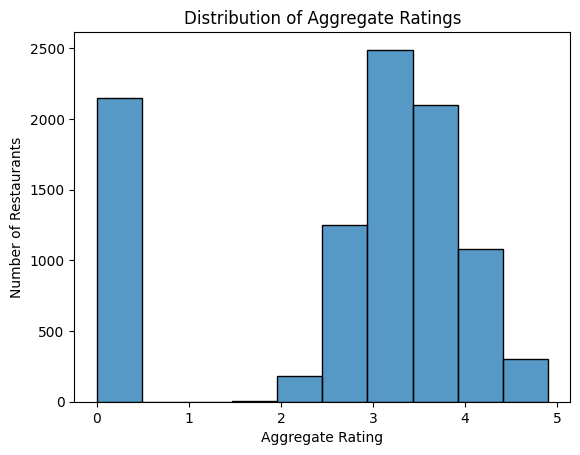

In [ ]:
sns.histplot(df['Aggregate rating'], bins=10)
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.show()

The distribution indicates that most restaurants receive mid-range ratings, with fewer restaurants at the extreme ends.

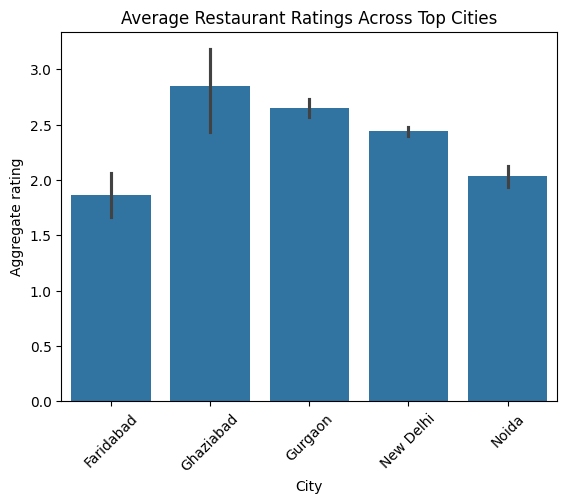

In [ ]:
top_cities = df['City'].value_counts().head(5).index

sns.barplot(x='City', y='Aggregate rating',
            data=df[df['City'].isin(top_cities)])
plt.xticks(rotation=45)
plt.title("Average Restaurant Ratings Across Top Cities")
plt.show()

Average restaurant ratings differ across cities, suggesting that location plays a role in customer experience.

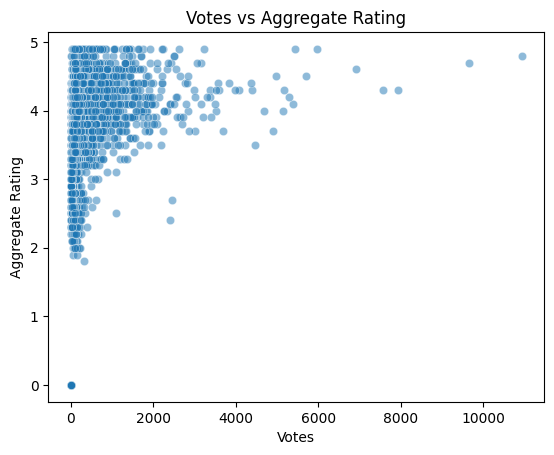

In [ ]:
sns.scatterplot(x='Votes', y='Aggregate rating', data=df, alpha=0.5)
plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.show()

Restaurants with higher customer engagement tend to receive better ratings, although the relationship is not strictly linear.

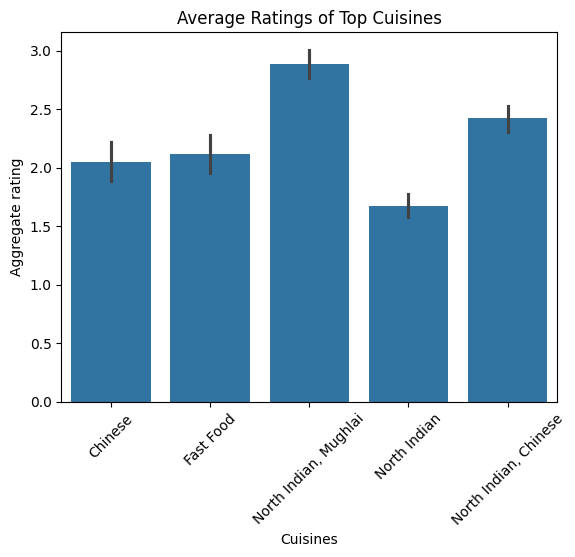

In [ ]:
top_cuisines = df['Cuisines'].value_counts().head(5).index

sns.barplot(x='Cuisines', y='Aggregate rating',
            data=df[df['Cuisines'].isin(top_cuisines)])
plt.xticks(rotation=45)
plt.title("Average Ratings of Top Cuisines")
plt.show()

Average ratings differ across cuisines, suggesting that certain cuisines are perceived more positively by customers.